In [1]:
import kagglehub
import os
import numpy as np
from sklearn.model_selection import StratifiedShuffleSplit
from PIL import Image, ImageTk
from random import sample
import seaborn as sns
import tkinter as tk
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, AveragePooling2D, GlobalAveragePooling2D, GlobalMaxPooling2D
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

# Загрузка данных

In [2]:
os.environ["KAGGLEHUB_CACHE"] = "data/kagglehub_cache"

path = kagglehub.dataset_download(
    "balabaskar/tom-and-jerry-image-classification"
)

print("Dataset path:", path)

Dataset path: data/kagglehub_cache\datasets\balabaskar\tom-and-jerry-image-classification\versions\3


# Подготовка выборок

In [3]:
def load_images_from_folders(tom_path, jerry_path):
    images = []
    labels = []

    for file in os.listdir(jerry_path):
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            img_path = os.path.join(jerry_path, file)
            image = Image.open(img_path).convert('L')
            image = image.resize((128, 128))
            image_array = np.array(image) / 255.0
            image_array = np.expand_dims(image_array, axis=-1)
            images.append(image_array)
            labels.append(0)

    for file in os.listdir(tom_path):
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            img_path = os.path.join(tom_path, file)
            image = Image.open(img_path).convert('L')
            image = image.resize((128, 128))
            image_array = np.array(image) / 255.0
            image_array = np.expand_dims(image_array, axis=-1)
            images.append(image_array)
            labels.append(1)

    return np.array(images), np.array(labels)


tom_path = r"data\kagglehub_cache\datasets\balabaskar\tom-and-jerry-image-classification\versions\3\tom_and_jerry\tom_and_jerry\tom"
jerry_path = r"data\kagglehub_cache\datasets\balabaskar\tom-and-jerry-image-classification\versions\3\tom_and_jerry\tom_and_jerry\jerry"

X, Y = load_images_from_folders(tom_path, jerry_path)

sss = StratifiedShuffleSplit(n_splits=1, train_size=0.8, random_state=42)
train_idx, test_idx = next(sss.split(X, Y))

x_train, x_test = X[train_idx], X[test_idx]
y_train, y_test = Y[train_idx].astype(np.float32), Y[test_idx].astype(np.float32)

In [4]:
print(x_train.shape)
print(x_test.shape)

(2536, 128, 128, 1)
(634, 128, 128, 1)


# Проверка сбалансированности классов

In [43]:
def check_class_balance(labels, name):
    unique, counts = np.unique(labels, return_counts=True)

    print(f"\n{name} распределение:")
    for u, c in zip(unique, counts):
        class_name = "Джери (0)" if u == 0 else "Том (1)"
        percent = (c / len(labels)) * 100
        print(f"{class_name}: {c} изображений ({percent:.2f}%)")

check_class_balance(y_train, "Train выборка")
check_class_balance(y_test, "Test выборка")


Train выборка распределение:
Джери (0): 992 изображений (39.12%)
Том (1): 1544 изображений (60.88%)

Test выборка распределение:
Джери (0): 248 изображений (39.12%)
Том (1): 386 изображений (60.88%)


# Max poolling

In [45]:
# описание модели
model_max = Sequential([
    Input(shape=(128,128,1)),

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

In [46]:
# сборка модели
model_max.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# обучение модели
model_max.fit(x_train, y_train, batch_size=16,
          epochs=5,
          validation_data=(x_test, y_test))

Epoch 1/5
159/159 ━━━━━━━━━━━━━━━━━━━━ 11s 57ms/step - accuracy: 0.6593 - loss: 0.6249 - val_accuracy: 0.6956 - val_loss: 0.5577
Epoch 2/5
159/159 ━━━━━━━━━━━━━━━━━━━━ 8s 52ms/step - accuracy: 0.7756 - loss: 0.4866 - val_accuracy: 0.8281 - val_loss: 0.4068
Epoch 3/5
159/159 ━━━━━━━━━━━━━━━━━━━━ 8s 49ms/step - accuracy: 0.8419 - loss: 0.3702 - val_accuracy: 0.8880 - val_loss: 0.3184
Epoch 4/5
159/159 ━━━━━━━━━━━━━━━━━━━━ 8s 51ms/step - accuracy: 0.8864 - loss: 0.2909 - val_accuracy: 0.8785 - val_loss: 0.2935
Epoch 5/5
159/159 ━━━━━━━━━━━━━━━━━━━━ 8s 52ms/step - accuracy: 0.9077 - loss: 0.2290 - val_accuracy: 0.8880 - val_loss: 0.2717


In [8]:
# проверка модели на тестовых данных
predictions_max = model_max.predict(x_test)
binary_predictions_max = (predictions_max > 0.5).astype(int).flatten()
accuracy_max = np.mean(y_test == binary_predictions_max)
print(f'Точность предсказания на тестовых данных : {accuracy_max * 100:.5f}%')

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step
Точность предсказания на тестовых данных : 88.95899%



Метрики классификации:
              precision    recall  f1-score   support

       Джери       0.93      0.77      0.85       248
         Том       0.87      0.96      0.91       386

    accuracy                           0.89       634
   macro avg       0.90      0.87      0.88       634
weighted avg       0.89      0.89      0.89       634



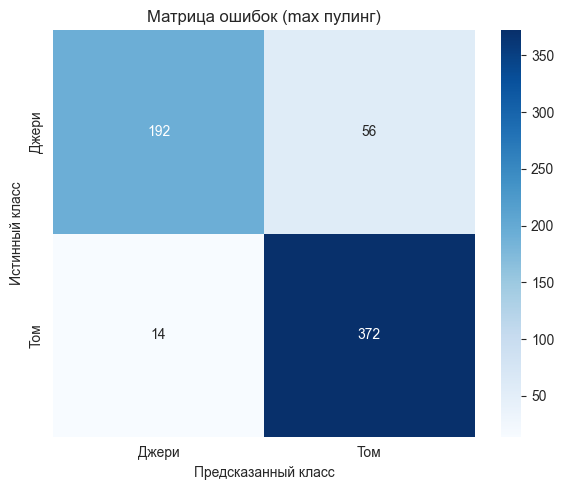

In [9]:
cm_max = confusion_matrix(y_test, binary_predictions_max)

print("\nМетрики классификации:")
print(classification_report(
    y_test,
    binary_predictions_max,
    target_names=['Джери', 'Том']
))

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_max,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Джери", "Том"],
    yticklabels=["Джери", "Том"],
    cbar=True
)

plt.title("Матрица ошибок (max пулинг)")
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")

plt.tight_layout()
plt.show()

# Average Pooling

In [10]:
# описание модели
model_avg = Sequential([
    Input(shape=(128,128,1)),

    Conv2D(32, (3,3), activation='relu'),
    AveragePooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    AveragePooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    AveragePooling2D(2,2),

    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

In [11]:
# сборка модели
model_avg.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

# обучение модели
model_avg.fit(x_train, y_train, batch_size=16,
              epochs=5,
              validation_data=(x_test, y_test))

Epoch 1/5
159/159 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step - accuracy: 0.6195 - loss: 0.6662 - val_accuracy: 0.6735 - val_loss: 0.6291
Epoch 2/5
159/159 ━━━━━━━━━━━━━━━━━━━━ 7s 43ms/step - accuracy: 0.6640 - loss: 0.6205 - val_accuracy: 0.7145 - val_loss: 0.5366
Epoch 3/5
159/159 ━━━━━━━━━━━━━━━━━━━━ 7s 45ms/step - accuracy: 0.7342 - loss: 0.5532 - val_accuracy: 0.7618 - val_loss: 0.4887
Epoch 4/5
159/159 ━━━━━━━━━━━━━━━━━━━━ 8s 47ms/step - accuracy: 0.7882 - loss: 0.4502 - val_accuracy: 0.8375 - val_loss: 0.3989
Epoch 5/5
159/159 ━━━━━━━━━━━━━━━━━━━━ 7s 45ms/step - accuracy: 0.8304 - loss: 0.3728 - val_accuracy: 0.8076 - val_loss: 0.4027


In [12]:
# проверка модели на тестовых данных
predictions_avg = model_avg.predict(x_test)
binary_predictions_avg = (predictions_avg > 0.5).astype(int).flatten()
accuracy_avg = np.mean(y_test == binary_predictions_max)
print(f'Точность предсказания на тестовых данных : {accuracy_avg * 100:.5f}%')

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step
Точность предсказания на тестовых данных : 88.95899%



Метрики классификации:
              precision    recall  f1-score   support

       Джери       0.89      0.58      0.70       248
         Том       0.78      0.95      0.86       386

    accuracy                           0.81       634
   macro avg       0.83      0.77      0.78       634
weighted avg       0.82      0.81      0.80       634



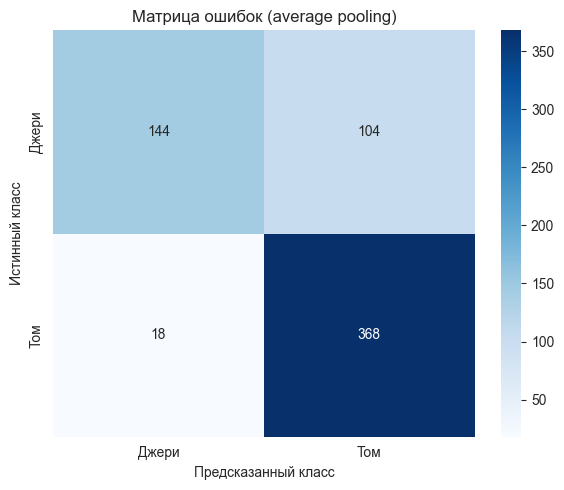

In [28]:
cm_avg = confusion_matrix(y_test, binary_predictions_avg)

print("\nМетрики классификации:")
print(classification_report(
    y_test,
    binary_predictions_avg,
    target_names=['Джери', 'Том']
))

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_avg,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Джери", "Том"],
    yticklabels=["Джери", "Том"],
    cbar=True
)

plt.title("Матрица ошибок (average pooling)")
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")

plt.tight_layout()
plt.show()

# Global Average Pooling

In [14]:
# описание модели
model_global_avg = Sequential([
    Input(shape=(128,128,1)),

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    GlobalAveragePooling2D(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

In [15]:
# сборка модели
model_global_avg.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

# обучение модели
model_global_avg.fit(x_train, y_train, batch_size=16,
              epochs=5,
              validation_data=(x_test, y_test))

Epoch 1/5
159/159 ━━━━━━━━━━━━━━━━━━━━ 8s 41ms/step - accuracy: 0.6100 - loss: 0.6619 - val_accuracy: 0.6073 - val_loss: 0.6481
Epoch 2/5
159/159 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - accuracy: 0.6577 - loss: 0.6346 - val_accuracy: 0.7035 - val_loss: 0.6121
Epoch 3/5
159/159 ━━━━━━━━━━━━━━━━━━━━ 7s 43ms/step - accuracy: 0.7090 - loss: 0.5870 - val_accuracy: 0.7161 - val_loss: 0.5681
Epoch 4/5
159/159 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step - accuracy: 0.7397 - loss: 0.5517 - val_accuracy: 0.7429 - val_loss: 0.5505
Epoch 5/5
159/159 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - accuracy: 0.7535 - loss: 0.5236 - val_accuracy: 0.7603 - val_loss: 0.5091


In [16]:
# проверка модели на тестовых данных
predictions_global_avg = model_global_avg.predict(x_test)
binary_predictions_global_avg = (predictions_global_avg > 0.5).astype(int).flatten()
accuracy_global_avg = np.mean(y_test == binary_predictions_global_avg)
print(f'Точность предсказания на тестовых данных : {accuracy_global_avg * 100:.5f}%')

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step
Точность предсказания на тестовых данных : 76.02524%



Метрики классификации:
              precision    recall  f1-score   support

       Джери       0.83      0.48      0.61       248
         Том       0.74      0.94      0.83       386

    accuracy                           0.76       634
   macro avg       0.79      0.71      0.72       634
weighted avg       0.78      0.76      0.74       634



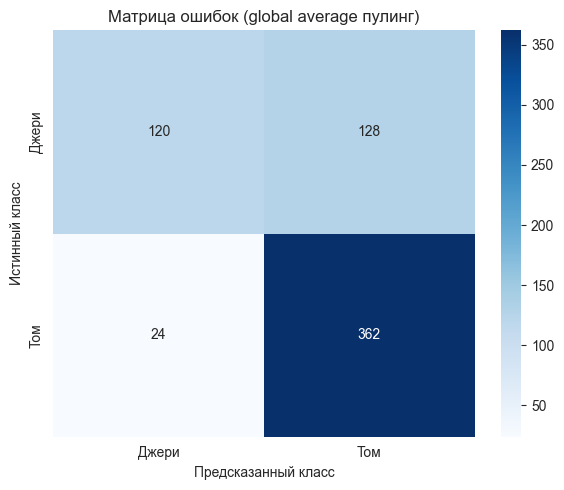

In [17]:
cm_global_avg = confusion_matrix(y_test, binary_predictions_global_avg)

print("\nМетрики классификации:")
print(classification_report(
    y_test,
    binary_predictions_global_avg,
    target_names=['Джери', 'Том']
))

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_global_avg,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Джери", "Том"],
    yticklabels=["Джери", "Том"],
    cbar=True
)

plt.title("Матрица ошибок (global average пулинг)")
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")

plt.tight_layout()
plt.show()

# Global Max Pooling

In [18]:
# описание модели
model_global_max = Sequential([
    Input(shape=(128,128,1)),

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    GlobalMaxPooling2D(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

In [19]:
# сборка модели
model_global_max.compile(optimizer='adam',
                         loss='binary_crossentropy',
                         metrics=['accuracy'])

# обучение модели
model_global_max.fit(x_train, y_train, batch_size=16,
                     epochs=5,
                     validation_data=(x_test, y_test))

Epoch 1/5
159/159 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - accuracy: 0.6073 - loss: 0.6574 - val_accuracy: 0.6073 - val_loss: 0.6086
Epoch 2/5
159/159 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step - accuracy: 0.6983 - loss: 0.5783 - val_accuracy: 0.7855 - val_loss: 0.5049
Epoch 3/5
159/159 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - accuracy: 0.7812 - loss: 0.4710 - val_accuracy: 0.8107 - val_loss: 0.4162
Epoch 4/5
159/159 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - accuracy: 0.8159 - loss: 0.4038 - val_accuracy: 0.6120 - val_loss: 0.7070
Epoch 5/5
159/159 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - accuracy: 0.8474 - loss: 0.3500 - val_accuracy: 0.8549 - val_loss: 0.3521


In [20]:
# проверка модели на тестовых данных
predictions_global_max = model_global_max.predict(x_test)
binary_predictions_global_max = (predictions_global_max > 0.5).astype(int).flatten()
accuracy_global_max = np.mean(y_test == binary_predictions_global_max)
print(f'Точность предсказания на тестовых данных : {accuracy_global_max * 100:.5f}%')

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step
Точность предсказания на тестовых данных : 85.48896%



Метрики классификации:
              precision    recall  f1-score   support

       Джери       0.87      0.74      0.80       248
         Том       0.85      0.93      0.89       386

    accuracy                           0.85       634
   macro avg       0.86      0.83      0.84       634
weighted avg       0.86      0.85      0.85       634



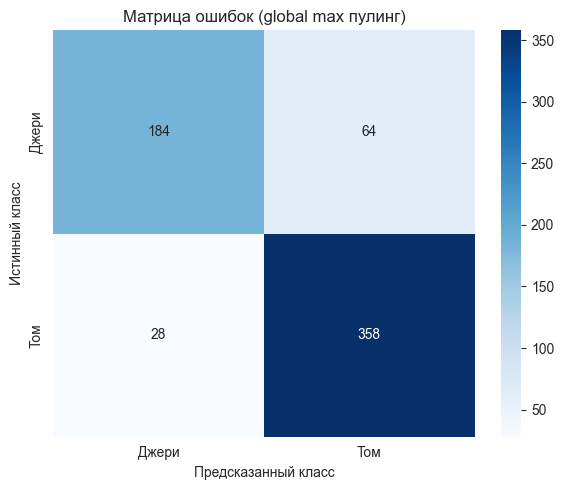

In [21]:
cm_global_max = confusion_matrix(y_test, binary_predictions_global_max)

print("\nМетрики классификации:")
print(classification_report(
    y_test,
    binary_predictions_global_max,
    target_names=['Джери', 'Том']
))

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_global_max,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Джери", "Том"],
    yticklabels=["Джери", "Том"],
    cbar=True
)

plt.title("Матрица ошибок (global max пулинг)")
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")

plt.tight_layout()
plt.show()

# Mixed Pooling

In [22]:
# описание модели
model_mixed = Sequential([
    Input(shape=(128,128,1)),

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    AveragePooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

In [23]:
# сборка модели
model_mixed.compile(optimizer='adam',
                         loss='binary_crossentropy',
                         metrics=['accuracy'])

# обучение модели
model_mixed.fit(x_train, y_train, batch_size=16,
                     epochs=5,
                     validation_data=(x_test, y_test))

Epoch 1/5
159/159 ━━━━━━━━━━━━━━━━━━━━ 8s 45ms/step - accuracy: 0.6562 - loss: 0.6221 - val_accuracy: 0.7571 - val_loss: 0.5255
Epoch 2/5
159/159 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - accuracy: 0.7768 - loss: 0.4831 - val_accuracy: 0.8013 - val_loss: 0.4226
Epoch 3/5
159/159 ━━━━━━━━━━━━━━━━━━━━ 7s 44ms/step - accuracy: 0.8395 - loss: 0.3703 - val_accuracy: 0.8438 - val_loss: 0.3612
Epoch 4/5
159/159 ━━━━━━━━━━━━━━━━━━━━ 7s 44ms/step - accuracy: 0.8758 - loss: 0.3016 - val_accuracy: 0.8817 - val_loss: 0.3111
Epoch 5/5
159/159 ━━━━━━━━━━━━━━━━━━━━ 7s 44ms/step - accuracy: 0.9105 - loss: 0.2227 - val_accuracy: 0.8738 - val_loss: 0.3490


In [24]:
# проверка модели на тестовых данных
predictions_mixed = model_mixed.predict(x_test)
binary_predictions_mixed = (predictions_mixed > 0.5).astype(int).flatten()
accuracy_mixed = np.mean(y_test == binary_predictions_mixed)
print(f'Точность предсказания на тестовых данных : {accuracy_mixed * 100:.5f}%')

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step
Точность предсказания на тестовых данных : 87.38170%



Метрики классификации:
              precision    recall  f1-score   support

       Джери       0.89      0.78      0.83       248
         Том       0.87      0.94      0.90       386

    accuracy                           0.87       634
   macro avg       0.88      0.86      0.86       634
weighted avg       0.87      0.87      0.87       634



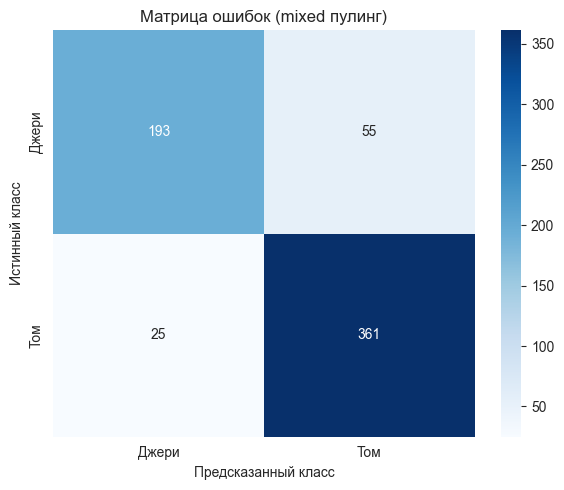

In [25]:
cm_mixed = confusion_matrix(y_test, binary_predictions_mixed)

print("\nМетрики классификации:")
print(classification_report(
    y_test,
    binary_predictions_mixed,
    target_names=['Джери', 'Том']
))

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_mixed,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Джери", "Том"],
    yticklabels=["Джери", "Том"],
    cbar=True
)

plt.title("Матрица ошибок (mixed пулинг)")
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")

plt.tight_layout()
plt.show()

# Количество параметров

In [26]:
print("Max Pooling")
model_max.summary()
print("Average Pooling")
model_avg.summary()
print("Global Average Pooling")
model_global_avg.summary()
print("Global Max Pooling")
model_global_max.summary()
print("Mixed Pooling")
model_mixed.summary()

Max Pooling


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     1,605,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,095,301 (19.44 MB)

 Trainable params: 1,698,433 (6.48 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_3             │ (None, 30, 30, 64)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │     1,605,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,095,301 (19.44 MB)

 Trainable params: 1,698,433 (6.48 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,396,868 (12.96 MB)

In [44]:
photos = []
labels_widgets = []

window = tk.Tk()
window.title("Примеры предсказаний")

# выбираем 9 случайных изображений
img_indxs = sample(range(len(x_test)), 9)
labels_names = ["Джери", "Том"]

for i, idx in enumerate(img_indxs):
    img = x_test[idx].squeeze()
    img = (img * 255.0).clip(0, 255).astype(np.uint8)

    pil_image = Image.fromarray(img, mode='L').copy()
    photo = ImageTk.PhotoImage(pil_image)
    photos.append(photo)  # держим ссылку

    pred = (model_max.predict(np.expand_dims(x_test[idx], axis=0)) > 0.5).astype(int).flatten()[0]

    true_label = labels_names[int(y_test[idx])]
    pred_label = labels_names[int(pred)]

    label = tk.Label(
        window,
        image=photo,
        text=f"Истинный класс: {true_label}\nПредсказанный класс: {pred_label}",
        compound="top"
    )
    label.image = photo
    labels_widgets.append(label)

    row = i // 3
    col = i % 3
    label.grid(row=row, column=col, padx=10, pady=10)

window.mainloop()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step
